In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, pipeline
import torch
import numpy as np

tokenizer = DistilBertTokenizerFast.from_pretrained("dhruvpal/fake-news-bert")
model = DistilBertForSequenceClassification.from_pretrained("dhruvpal/fake-news-bert")

def predict(texts):
    allprobs = np.zeros((len(texts), 2))

    with torch.no_grad():
        for i, text in enumerate(texts):
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=1024)
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            allprobs[i] = probs.numpy()

    return allprobs
    # return "Fake News" if torch.argmax(probs) == 1 else "Real News"

predict(["Ala ma", "kota"])

2026-01-15 04:43:20.855172: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768448600.873564   14260 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768448600.878966   14260 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768448600.891908   14260 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768448600.891927   14260 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768448600.891928   14260 computation_placer.cc:177] computation placer alr

array([[4.25847211e-05, 9.99957442e-01],
       [4.44498801e-05, 9.99955535e-01]])

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

true = f"{path}/True.csv"
fake = f"{path}/Fake.csv"

In [ ]:
import pandas as pd 

dft = pd.read_csv(true)
dff = pd.read_csv(fake)

In [4]:
import shap

BG_N = 100

background_texts = pd.concat([
    dff.sample(BG_N, random_state=42),
    dft.sample(BG_N, random_state=42)
])['title'].dropna().tolist()

eval_texts = pd.concat([dff, dft])['title'].dropna().tolist()

In [5]:
explainer = shap.Explainer(predict, tokenizer)

shap_values = explainer(eval_texts[:10])

PartitionExplainer explainer:  20%|██        | 2/10 [00:00<?, ?it/s]

  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer:  40%|████      | 4/10 [00:17<00:16,  2.81s/it]

  0%|          | 0/380 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 6/10 [00:26<00:14,  3.65s/it]

  0%|          | 0/306 [00:00<?, ?it/s]

PartitionExplainer explainer:  70%|███████   | 7/10 [00:32<00:13,  4.35s/it]

  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|████████  | 8/10 [00:38<00:10,  5.09s/it]

  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer:  90%|█████████ | 9/10 [00:45<00:05,  5.59s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [00:57<00:00,  7.50s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [01:05,  7.33s/it]                        


In [8]:
i = 0  # sample index
shap.initjs()

plots_html = shap.plots.text(shap_values, display=False)
with open("shap_text.html", "w", encoding="utf-8") as f:
    f.write(plots_html)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def top_words(shap_values, sample_idx=0, class_idx=1, top_k=10):
    dfs, values, tokens = [], None, None

    for sample_idx in range(10):
        values = shap_values.values[sample_idx][:, class_idx]
        tokens = shap_values.data[sample_idx]

        df = pd.DataFrame({
            "token": tokens,
            "importance": values
        })

        df = df[df.token.str.strip() != ""]
        df["abs"] = df.importance.abs()

        dfs.append(df.sort_values("abs", ascending=False).head(top_k))

    return dfs


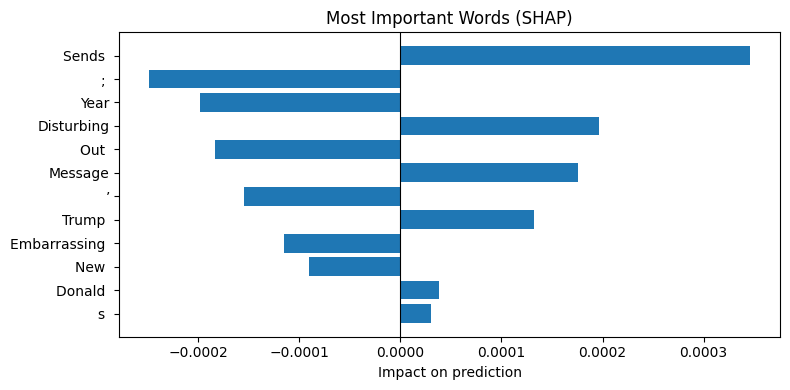

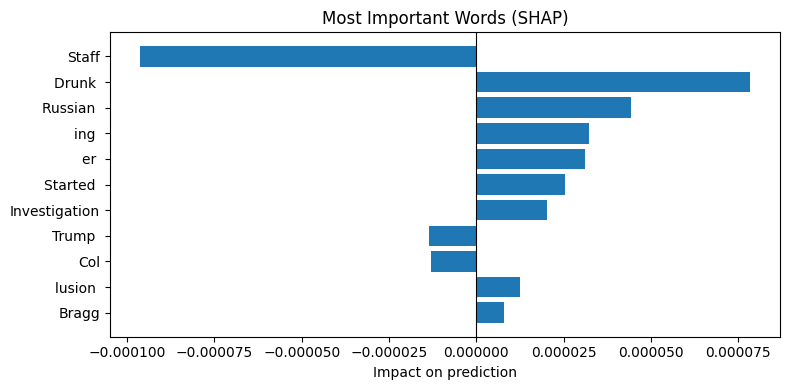

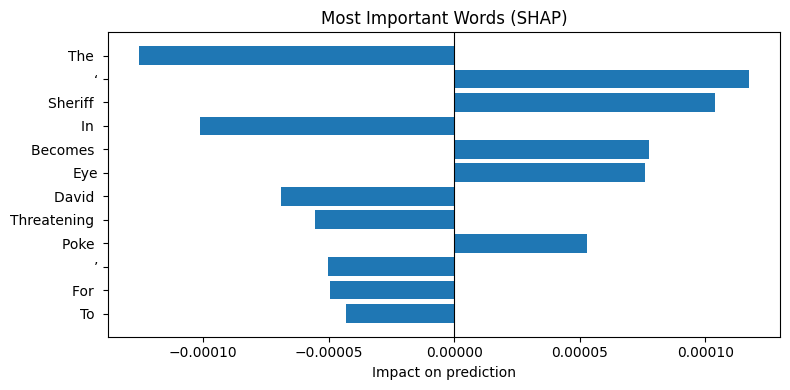

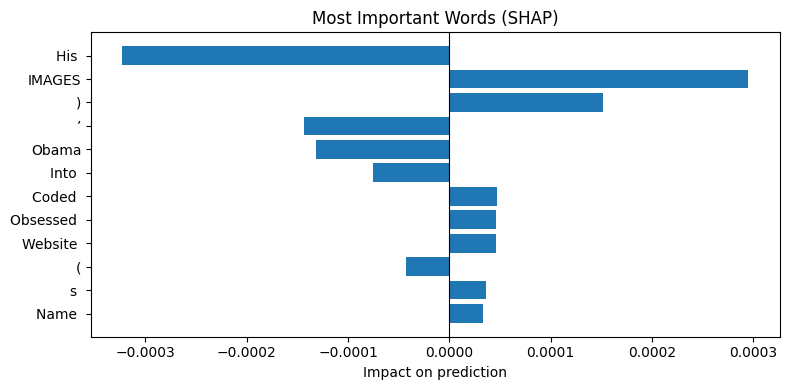

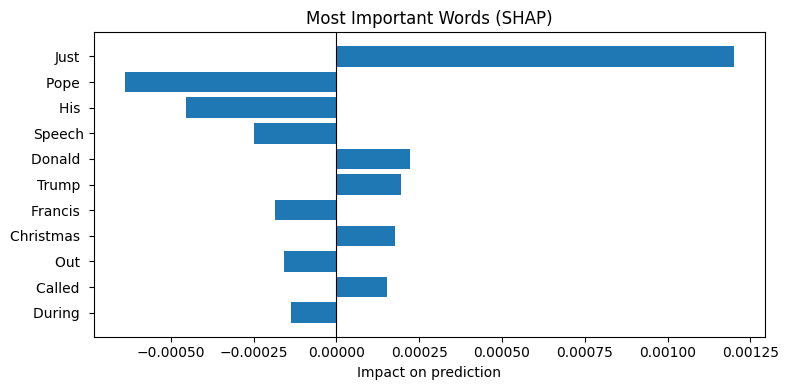

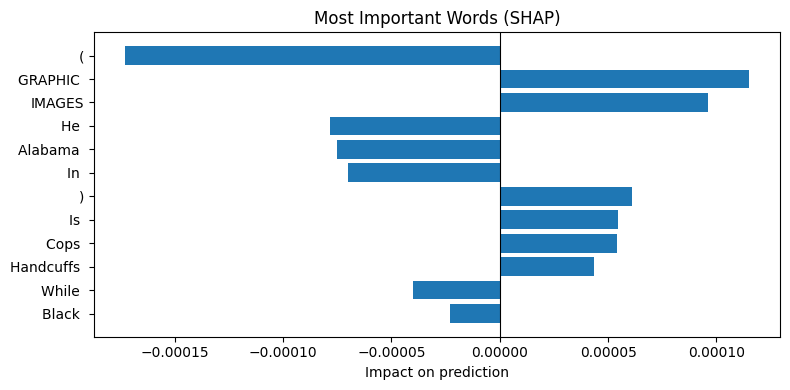

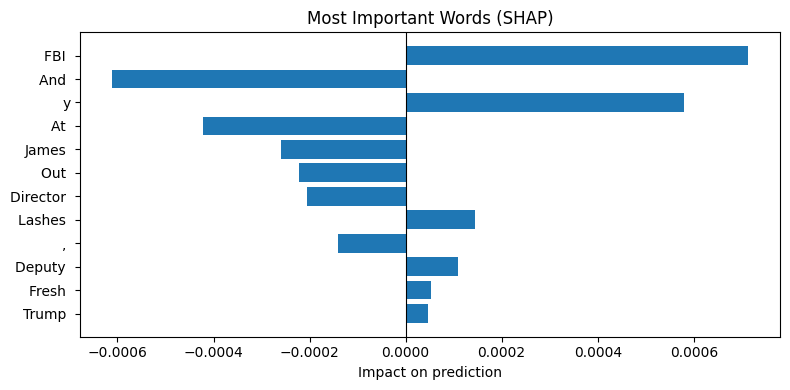

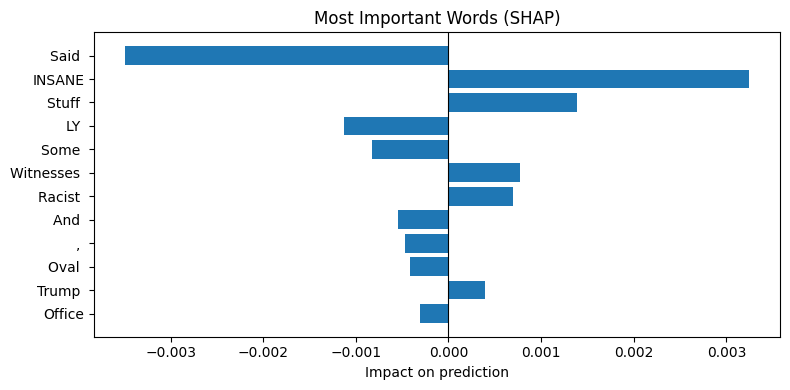

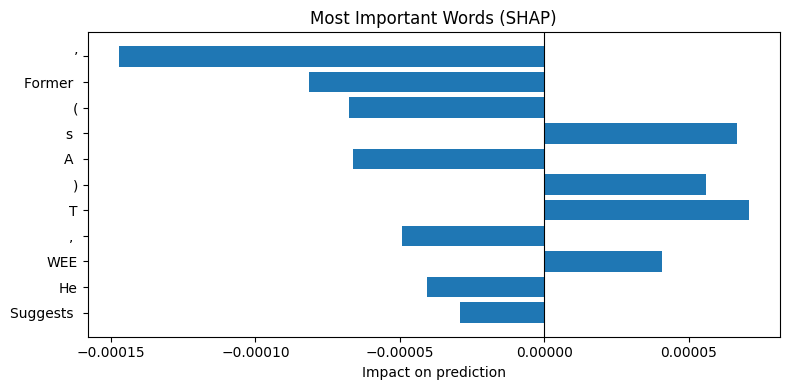

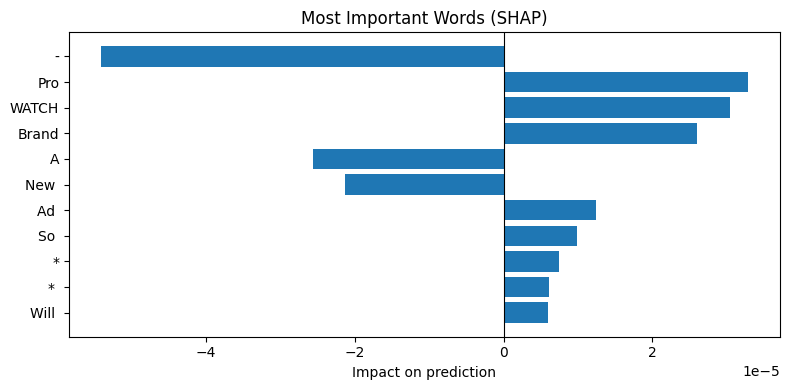

In [22]:
dfs = top_words(shap_values, top_k=12)

for i in range(10):
    plt.figure(figsize=(8, 4))
    plt.barh(
        dfs[i].token[::-1],
        dfs[i].importance[::-1]
    )
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Most Important Words (SHAP)")
    plt.xlabel("Impact on prediction")
    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

EVAL_N = 500

eval_texts = pd.concat([dff.iloc[:EVAL_N], dft.iloc[:EVAL_N]])['text'].dropna().tolist()
eval_labels = np.array([1] * EVAL_N + [0] * EVAL_N) 

probs = predict(eval_texts)              # shape (N, 2)
preds = np.argmax(probs, axis=1)       # predicted class

accuracy = accuracy_score(eval_labels, preds)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.5720
